In [25]:
import pandas as pd
import glob
import re
import os
from functions import *

Clean NTN 

In [ ]:
# Grab all CSV files
folder = "data_origin/omi_ntn/residential"

all_files = glob.glob(os.path.join(folder, "*.csv"))

out_dir = "datasets/omi_estimate"
os.makedirs(out_dir, exist_ok=True)


# Concatenate all datasets into a single DataFrame
dfs = []

for i,f in enumerate(all_files):
    """
    Read every dataset in the folder as input.

    Extract year and semester from the file name.

    Select relevant columns.

    Return datasets with updated istat codes. 
    """
    # Extract filename without extension
    filename = os.path.splitext(os.path.basename(f))[0]

    # Extract year from filename
    match = re.search(r"_(\d{4})(?:_|$)", filename)
    year = int(match.group(1))
    
    # Read CSV, skip first title line
    df = pd.read_csv(f, sep=';')
    
    # Assign year to a new column
    df['year'] = year

    # Drop unnecessary columns
    df = df.drop(columns=['area', 'reg_name', 'prov_name'])

    # Strip commas from column names and NTN values
    df.columns = df.columns.str.strip(",")
    df["NTN"] = df["NTN"].astype(str).str.strip(",")

    # Use ',' as the decimal separator and convert to numeric (exlcude land_code)
    cols_to_convert = ["upto_50", "50_85", "85_115", "115_145", "over_145", "NTN"]
    df[cols_to_convert] = df[cols_to_convert].apply(
        lambda col: col.astype(str).str.replace(",", ".").astype(float)
    )    
    
    dfs.append(df)

# Concatenate all DataFrames into one
final_df = pd.concat(dfs, ignore_index=True)

# Sort by land_code, year
final_df = final_df.sort_values(by=['land_code', 'year'])

AttributeError: Can only use .str accessor with string values!

In [5]:
final_df.head()

,land_code,upto_50,50_85,85_115,115_145,over_145,"NTN,,,,,,",year
22972,"0,000000","0,000000","0,0",NaN,NaN,NaN,NaN,2017
22978,"0,000000","2,000000","4,0",NaN,NaN,NaN,NaN,2017
22981,"0,000000","2,500000","7,0",NaN,NaN,NaN,NaN,2017
22983,"0,000000","0,000000","4,0",NaN,NaN,NaN,NaN,2017
22985,"0,000000","0,000000","6,530000",NaN,NaN,NaN,NaN,2017


Import ISTAT codes

In [3]:
# Import ISTAT codes
df_istat = pd.read_csv('datasets/mun_istat_codes_non_normalized.csv')

In [4]:
# Merge with ISTAT codes
df_ntn_istat = pd.merge(df_ntn, df_istat[['land_code', 'mun_istat']], on = 'land_code', how = 'left')

# Drop land_code column
df_ntn_istat = df_ntn_istat.drop(columns = ['land_code'])

# Drop rows with missing values
df_ntn_istat = df_ntn_istat.dropna()

# Normalize ISTAT codes
df_ntn_istat['mun_istat'] = df_ntn_istat['mun_istat'].astype(int)
add_zeroes(df_ntn_istat, ['mun_istat'], 6)

,upto_50,50_85,85_115,115_145,over_145,NTN,year,mun_istat
0,2183,5067,3949,13.0,605.0,13104,2014,010001
1,0,35,3,25.0,1.0,10,2014,010002
2,2,633,625,375.0,3.0,2133,2014,010003
3,308,1017,95,10.0,3.0,3575,2014,010004
4,0,2,425,1.0,4.0,1125,2014,010005
...,...,...,...,...,...,...,...,...
83569,0,2,3,0.0,3.0,8,2015,046037
83570,0,4,125,417.0,897.0,2964,2015,097092
83571,0,0,0,0.0,0.0,0,2015,035046
83572,5,2125,2493,1267.0,1575.0,796,2015,037062


Save data

In [5]:
df_ntn_istat.to_csv('datasets/omi_ntn/omi_ntn_residential.csv', index=False)

In [6]:
df_ntn_istat[df_ntn_istat['mun_istat'] == '015146']

,upto_50,50_85,85_115,115_145,over_145,NTN,year,mun_istat
1209,266825,664367,354654,161532.0,139235.0,1586613,2014,015146
11463,526312,1034756,471714,202905.0,163003.0,239869,2024,015146
19026,524268,1082922,511472,198586.0,167543.0,2484791,2023,015146
26590,611105,126718,580846,225918.0,17666.0,2861709,2022,015146
34153,558495,11656,54731,225147.0,19838.0,2694932,2021,015146
41716,473593,918278,443026,177225.0,152857.0,2164979,2020,015146
49278,559368,1110524,530475,226637.0,196147.0,2623151,2019,015146
56877,500621,1037054,514801,216882.0,183237.0,2452595,2018,015146
64497,44219,12945,54175,21692.0,185742.0,237233,2017,015146
69475,390032,943821,479165,203067.0,176153.0,2192238,2016,015146


In [10]:
df_ntn_istat['sum'] = df_ntn_istat['upto_50'] + df_ntn_istat['50_85'] + df_ntn_istat['85_115'] + df_ntn_istat['115_145'] + df_ntn_istat['over_145']

In [11]:
df_ntn_istat[df_ntn_istat['mun_istat'] == '015146']

,upto_50,50_85,85_115,115_145,over_145,NTN,year,mun_istat,sum
1209,266825,664367,354654,161532.0,139235.0,1586613,2014,015146,1586613.0
11463,526312,1034756,471714,202905.0,163003.0,239869,2024,015146,2398690.0
19026,524268,1082922,511472,198586.0,167543.0,2484791,2023,015146,2484791.0
26590,611105,126718,580846,225918.0,17666.0,2861709,2022,015146,1562253.0
34153,558495,11656,54731,225147.0,19838.0,2694932,2021,015146,869867.0
41716,473593,918278,443026,177225.0,152857.0,2164979,2020,015146,2164979.0
49278,559368,1110524,530475,226637.0,196147.0,2623151,2019,015146,2623151.0
56877,500621,1037054,514801,216882.0,183237.0,2452595,2018,015146,2452595.0
64497,44219,12945,54175,21692.0,185742.0,237233,2017,015146,318773.0
69475,390032,943821,479165,203067.0,176153.0,2192238,2016,015146,2192238.0


<Axes: xlabel='year', ylabel='sum'>

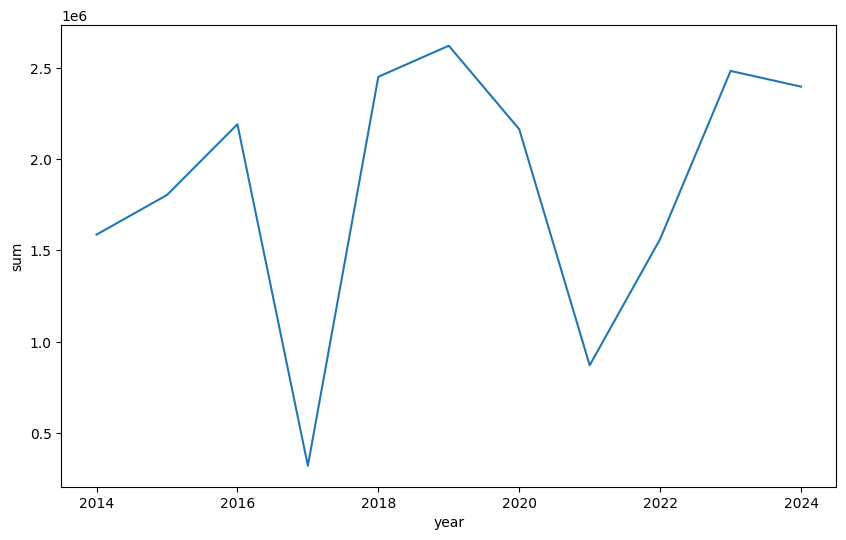

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,6))
sns.lineplot(data = df_ntn_istat[(df_ntn_istat['mun_istat'] == '015146')], x = 'year', y = 'sum')